In [1]:
import pandas as pd
import os.path as op
import platform
import glob
import os
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import pingouin

In [2]:
# Importing the files with reaction time and with the fitted parameters

if platform.system() == "Windows":
    wanted_dir = "/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals"
else:
    wanted_dir = "/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals"

V0_files = [file for file in glob.glob(wanted_dir + '/**/V0*', recursive=True)]
V1_files = [file for file in glob.glob(wanted_dir + '/**/V1*', recursive=True)]
spe_files = [file for file in glob.glob(wanted_dir + '/**/spe.npy', recursive=True)]

if platform.system() == "Windows":
    wanted_dir = "/data/sourcedata/behavior/modified_files"
else:
    wanted_dir = "/Volumes/SDrive/data/sourcedata/behavior/modified_files"

files = [os.path.join(root, name) for root, dirs, files in os.walk(wanted_dir) for name in files if name.endswith('savedValues.csv')]

files = files[:-1]
data_folder = '/Volumes/SDrive/data/'
# files


In [3]:
# Creating dataFrame with relevant indices and fitted values and RT. 
subjects = []
Vdiff_abs_data = []
Vdiff_data = []
Vsum_data = []
spe_data = []

for i in range(len(spe_files)):
    spe = np.load(spe_files[i])
    spe_data.append(spe)
    V0 = np.load(V0_files[i])
    V1 = np.load(V1_files[i])
    # V1_data.append(V0)
    Vdiff = (V1 - V0)[:, :-1]
    # Vdiff = (np.abs(V0-V1))[:,:-1]
    Vdiff_abs = np.abs(Vdiff)    
    Vdiff_data.append(Vdiff)
    Vdiff_abs_data.append(Vdiff_abs)
    Vsum = (V0+V1)[:,:-1]
    Vsum_data.append(Vsum)
    subjects.append(int(spe_files[i][-10:-8]))
    
# Flatten the data lists
Vdiff_data = np.array(Vdiff_data).flatten()
Vdiff_abs_data = np.array(Vdiff_abs_data).flatten()
Vsum_data = np.array(Vsum_data).flatten()
spe_data = np.array(spe_data).flatten()

# Create the index values for runNumber, trialNumber, and subject
subject = np.repeat(subjects, 6 * 60)
runNumber = np.repeat(np.arange(1, 7), 60 * 58)
trialNumber = np.tile(np.arange(1, 61), 6 * 58)

# Create the DataFrame
df = pd.DataFrame({
    'Vdiff_abs': Vdiff_abs_data,
    'Vdiff': Vdiff_data,    
    'Vsum': Vsum_data,
    'spe': spe_data,
    'runNumber': runNumber,
    'trialNumber': trialNumber,
    'subject': subject
})

# # Set the desired columns as the DataFrame's index
df.set_index(['runNumber', 'trialNumber', 'subject'], inplace=True)

RTdataset = []
for subject in subjects:
    file_path = op.join(data_folder, 'sourcedata', 'behavior', 'modified_files', f'modified_participant{subject:02d}_savedValues.csv')
    
    subject_rows = df.index.get_level_values('subject') == subject

    for key in ['responseTime', 'visual', 'audio', 'tactile', 'action']:
        # Read the CSV file and extract the 'responseTime' column
        data = pd.read_csv(file_path)[key]

        # Create the index values for the subject's rows in the DataFrame
        
        # Assign the 'responseTime' values to the corresponding subject in the DataFrame
        df.loc[subject_rows, key] = data.values


In [12]:
df.loc[df.audio.isnull(), 'modality']  = 'visuotactile'
df.loc[~df.audio.isnull(), 'modality']  = 'audiotactile'

In [5]:
import seaborn

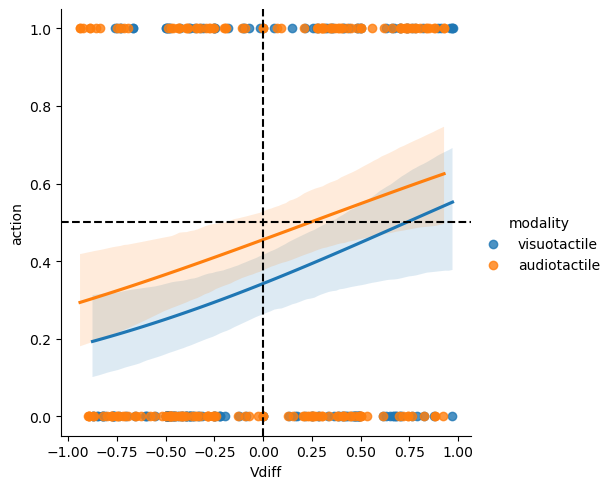

In [17]:
sns.lmplot(data=df.xs(1, 0, 'subject'), y='action', x='Vdiff', logistic=True, hue='modality')

plt.axhline(0.5, c='k', ls='--')
plt.axvline(0.0, c='k', ls='--')

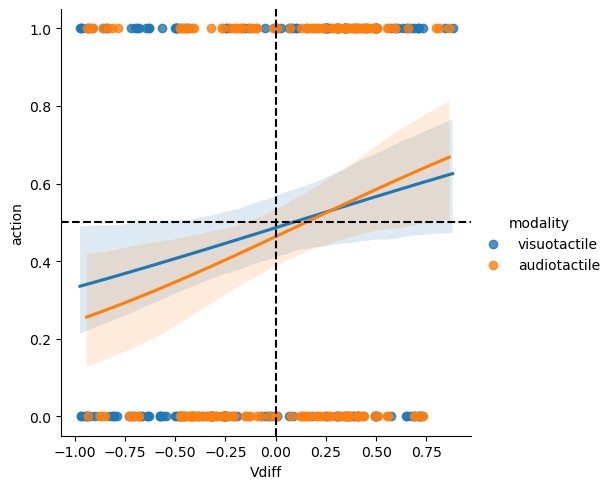

In [23]:
sns.lmplot(data=df.xs(2, 0, 'subject'), y='action', x='Vdiff', hue='modality', logistic=True)

plt.axhline(0.5, c='k', ls='--')
plt.axvline(0.0, c='k', ls='--')

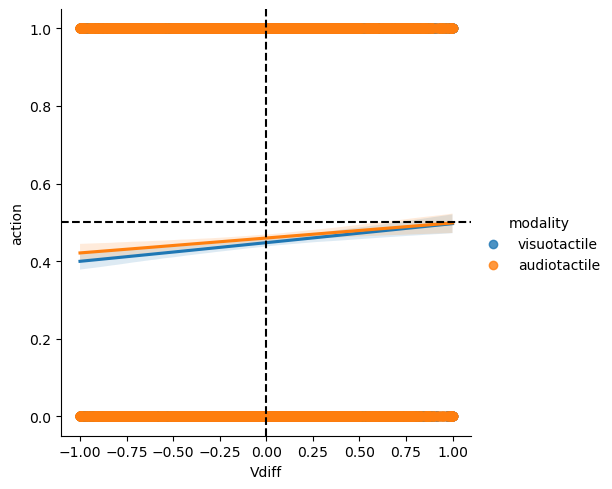

In [21]:
sns.lmplot(data=df, y='action', x='Vdiff', logistic=True, hue='modality')

plt.axhline(0.5, c='k', ls='--')
plt.axvline(0.0, c='k', ls='--')

In [18]:
df['response'] = df['action']
df['rt'] = df['action']

In [19]:
df_audio = df[~df.audio.isnull()]
df_tactile = df[~df.tactile.isnull()]

In [ ]:
import hddm

In [ ]:
v_reg = {'model': 'v ~ 0 + Vdiff + Vdiff:spe'}
reg_desc = [v_reg]

m1_audio = hddm.HDDMRegressor(df_audio, reg_desc, include=['v', 'a', 't', 'z'])

In [ ]:
v_reg = {'model': 'v ~ 0 + Vdiff'}
t0_reg = {'model': 't ~ 1 + spe'}
reg_desc = [v_reg, t0_reg]

m2_audio = hddm.HDDMRegressor(df_audio, reg_desc, include=['v', 'a', 't', 'z'])


In [ ]:
v_reg = {'model': 'v ~ 0 + Vdiff'}
a_reg = {'model': 'a ~ 1 + spe'}
reg_descr = [v_reg, a_reg]

m3_audio = hddm.HDDMRegressor(df_audio, reg_desc, include=['v', 'a', 't', 'z'])
